# Airbnb Market Intelligence

# 10 - Model Evaluation

## Objectives

- Load the trained model
- Evaluate performance
- Compare actual vs predicted values
- Analyze residuals
- Identify important features
- Perform cross validation

## Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.model_selection import cross_val_score

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/processed/airbnb_feature_engineered.csv")
df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,amenities_count,price_category,rating_category,bedroom_density,price_per_guest,overall_review_score,host_quality,review_count,estimated_monthly_revenue,host_size
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",Unknown,1.0,0.98,False,1.0,...,5,Budget,NaN,2.0,26.5,10.0,1,2.0,106.0,Single
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",Unknown,1.0,0.98,False,1.0,...,8,Standard,NaN,2.0,60.0,10.0,2,6.0,720.0,Single
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",Unknown,1.0,0.98,False,1.0,...,6,Budget,NaN,2.0,44.5,10.0,1,1.0,89.0,Single
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",Unknown,1.0,0.98,False,1.0,...,5,Budget,NaN,2.0,29.0,10.0,2,1.0,58.0,Single
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",Unknown,1.0,0.98,False,1.0,...,12,Budget,NaN,2.0,30.0,10.0,1,1.0,60.0,Single


In [3]:
drop_cols = [
    "listing_id",
    "name",
    "host_since",
    "host_location",
    "amenities"
]

X = df.drop(columns=drop_cols + ["price"])

y = df["price"]

In [4]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [5]:
rf_model = joblib.load("../models/random_forest_model.pkl")

In [6]:
pred = rf_model.predict(X_test)

In [7]:
print("R² :",round(r2_score(y_test,pred),3))

print("MAE:",round(mean_absolute_error(y_test,pred),2))

print("RMSE:",round(np.sqrt(mean_squared_error(y_test,pred)),2))

R² : 0.944
MAE: 12.55
RMSE: 628.82


In [8]:
train_pred=rf_model.predict(X_train)

print("Training R²:",round(r2_score(y_train,train_pred),3))

print("Testing R² :",round(r2_score(y_test,pred),3))

Training R²: 0.984
Testing R² : 0.944


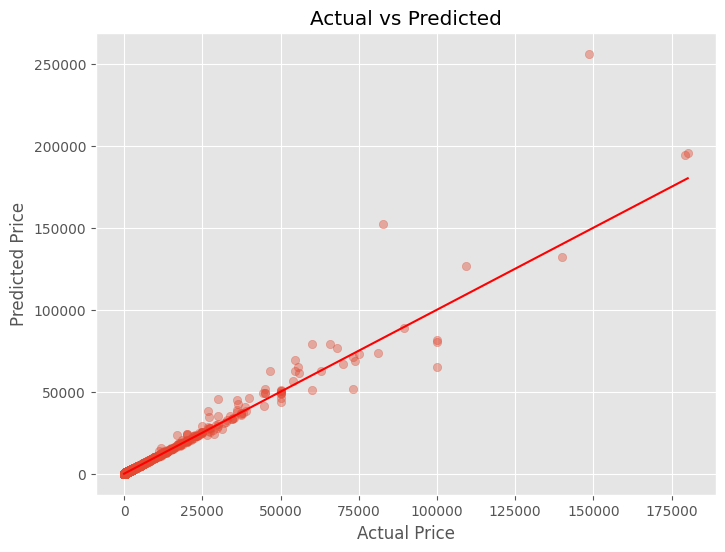

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred,
    alpha=0.4
)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color="red"
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

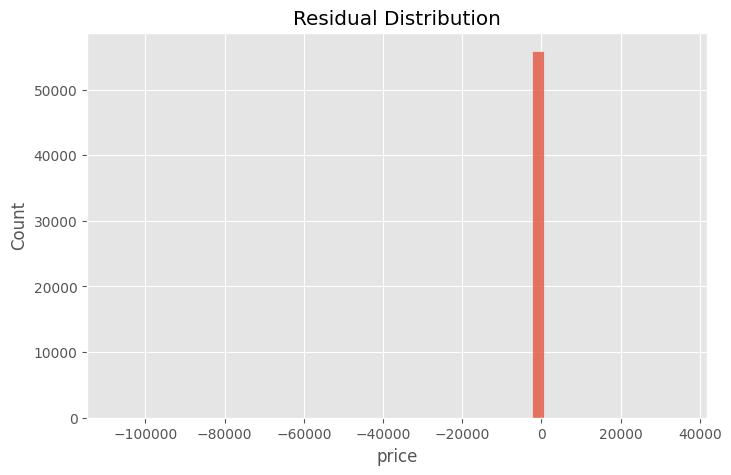

In [10]:
residual=y_test-pred

plt.figure(figsize=(8,5))

sns.histplot(
    residual,
    bins=50
)

plt.title("Residual Distribution")

plt.show()

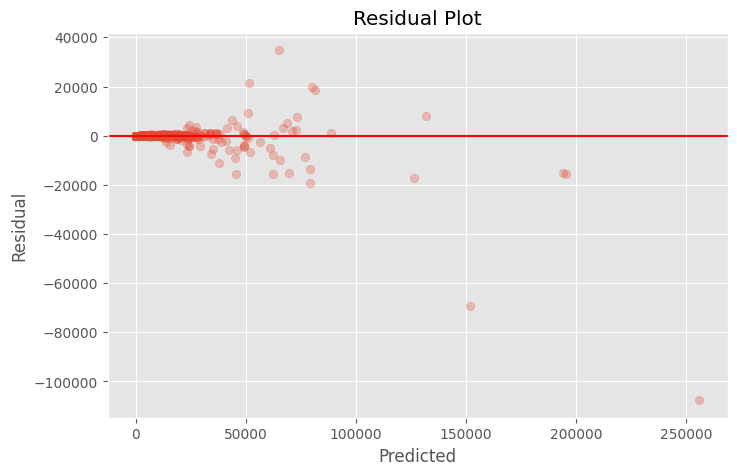

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(
    pred,
    residual,
    alpha=0.3
)

plt.axhline(
    0,
    color="red"
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [12]:
feature_names=rf_model.named_steps["preprocessor"].get_feature_names_out()

importance=rf_model.named_steps["model"].feature_importances_

fi=pd.DataFrame({

    "Feature":feature_names,

    "Importance":importance

})

fi=fi.sort_values(
    "Importance",
    ascending=False
)

fi.head(20)

,Feature,Importance
23,num__price_per_guest,0.659820
9,num__accommodates,0.095512
835,cat__price_category_Luxury,0.089174
834,cat__price_category_Budget,0.063967
22,num__bedroom_density,0.015985
7,num__latitude,0.008347
464,cat__neighbourhood_Sao Cristovao,0.007719
12,num__maximum_nights,0.006002
21,num__amenities_count,0.005989
20,num__host_experience_years,0.005950


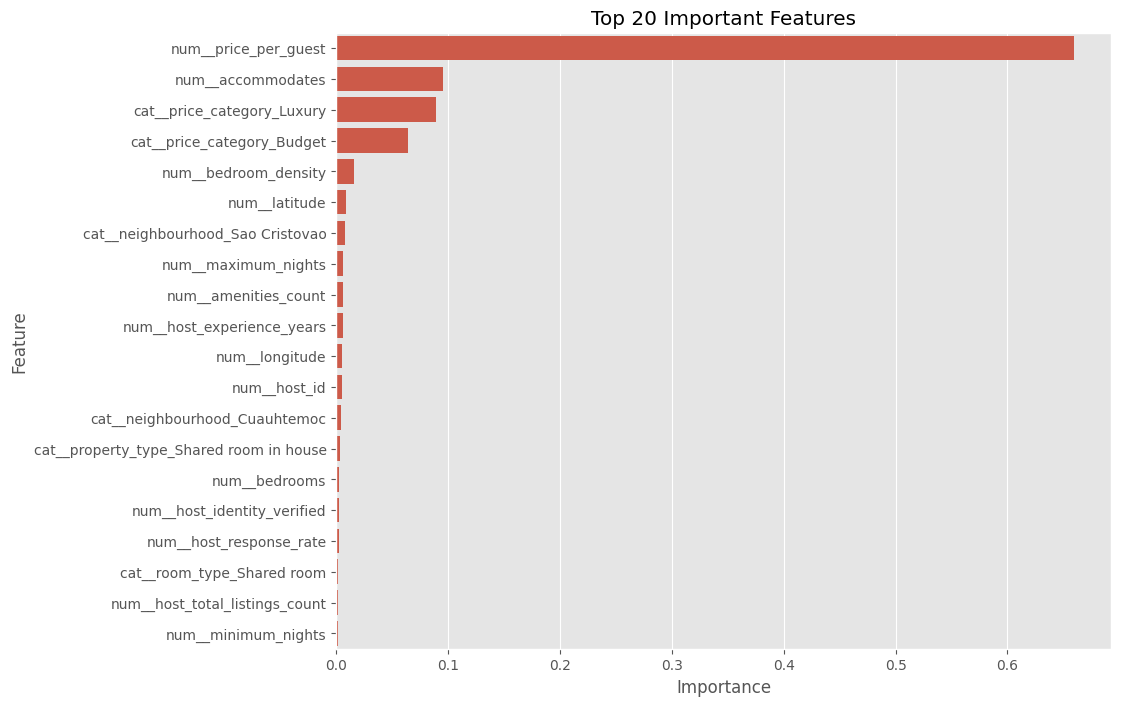

In [13]:
plt.figure(figsize=(10,8))

sns.barplot(

data=fi.head(20),

x="Importance",

y="Feature"

)

plt.title("Top 20 Important Features")

plt.show()

In [ ]:
scores=cross_val_score(rf_model,X,y,cv=5,
    scoring="r2",n_jobs=-1)

print(scores)
print()
print("Average R²:",round(scores.mean(),3))

In [ ]:
comparison=pd.DataFrame({
    "Actual":y_test,"Predicted":pred,"Error":y_test-pred
})

comparison.head(20)

In [ ]:
comparison.sort_values("Error",key=abs).head(20)

In [ ]:
comparison.sort_values("Error",key=abs,ascending=False).head(20)

In [ ]:
fi.to_csv("../reports/feature_importance.csv",
index=False
)

print("Feature Importance Saved")

# Conclusion

## Linear Regression

- R² ≈ 0.60

## Random Forest

- R² ≈ 0.94

Random Forest significantly outperformed Linear Regression.

The model captures nonlinear relationships and provides accurate price predictions.

Feature importance analysis identifies the strongest drivers of Airbnb pricing.

The model is suitable for deployment in the Streamlit application.